# Book Recommendation System

## Problem Statement
Build a recommendation system that suggests books to users based on collaborative filtering and popularity-based approaches. 

## Dataset Overview
- **books.csv**: Book metadata (ID, title, authors, publication year, ISBN, language, etc.)
- **ratings.csv**: User ratings (user_id, book_id, rating)
- **book_tags.csv**: Tags associated with books (book_id, tag_id, count)
- **tags.csv**: Tag descriptions (tag_id, tag_name)

## Recommender System Approach
1. **Popularity-Based Filtering**: Recommend books based on overall popularity and average ratings
2. **Collaborative Filtering**: Recommend books based on similar user-item patterns using cosine similarity

## Expected Outcomes
- Understand data relationships and distributions
- Clean and prepare data for modeling
- Build and compare recommendation models
- Create a function that recommends books for any user

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ModuleNotFoundError: No module named 'numpy'

## 1. Import Libraries

In [ ]:
ratings = pd.read_csv('../data/ratings.csv')
books = pd.read_csv('../data/books.csv')
books_tags = pd.read_csv('../data/book_tags.csv')
tags = pd.read_csv('../data/tags.csv')

In [ ]:
ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [ ]:
#Shows mean, min, max, distribution summary of the ratings
ratings.describe()

,user_id,book_id,rating
count,5.976479e+06,5.976479e+06,5.976479e+06
mean,2.622446e+04,2.006477e+03,3.919866e+00
std,1.541323e+04,2.468499e+03,9.910868e-01
min,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.281300e+04,1.980000e+02,3.000000e+00
50%,2.593800e+04,8.850000e+02,4.000000e+00
75%,3.950900e+04,2.973000e+03,5.000000e+00
max,5.342400e+04,1.000000e+04,5.000000e+00


In [ ]:
#Total counts
print("Total ratings : ", len(ratings))
print("Total unique users : ", ratings['user_id'].nunique())
print("Total unique books : ", ratings['book_id'].nunique())

Total ratings :  5976479
Total unique users :  53424
Total unique books :  10000


# 2 . Understanding the relationships

In [ ]:
books_tags.columns

Index(['goodreads_book_id', 'tag_id', 'count'], dtype='object')

In [ ]:
books.columns

Index(['book_id', 'goodreads_book_id', 'best_book_id', 'work_id',
       'books_count', 'isbn', 'isbn13', 'authors', 'original_publication_year',
       'original_title', 'title', 'language_code', 'average_rating',
       'ratings_count', 'work_ratings_count', 'work_text_reviews_count',
       'ratings_1', 'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5',
       'image_url', 'small_image_url'],
      dtype='object')

In [ ]:
ratings.columns

Index(['user_id', 'book_id', 'rating'], dtype='object')

In [ ]:
tags.columns

Index(['tag_id', 'tag_name'], dtype='object')

In [ ]:
# one user and their ratings

user_id_sample = ratings['user_id'].iloc[0]
user_ratings = ratings[ratings['user_id']==user_id_sample]
print(f"user {user_id_sample} has {len(user_ratings)} ratings") # One user has many ratings


user 1 has 117 ratings


In [ ]:
# one book and its ratings

book_id_sample = ratings['book_id'].iloc[0]
book_ratings = ratings[ratings['book_id'] == book_id_sample]
print(f"book_id {book_id_sample} has {len(book_ratings)} ratings") # one book has many ratings

book_id 258 has 3531 ratings


In [ ]:
# one book and its tags
book_id_sample_tags = books_tags['goodreads_book_id'].iloc[0]
book_tags_example = books_tags[books_tags['goodreads_book_id'] == book_id_sample_tags]
print(f"Book {book_id_sample_tags} has {len(book_tags_example)} tags") # one book has many tags

Book 1 has 100 tags


In [ ]:
# Summary statistics

print(f"Ratings per user - Min: {ratings.groupby('user_id').size().min()}, Max: {ratings.groupby('user_id').size().max()}, Avg: {ratings.groupby('user_id').size().mean():.0f}")
print(f"Ratings per book - Min: {ratings.groupby('book_id').size().min()}, Max: {ratings.groupby('book_id').size().max()}, Avg: {ratings.groupby('book_id').size().mean():.0f}")
print(f"Tags per book - Min: {books_tags.groupby('goodreads_book_id').size().min()}, Max: {books_tags.groupby('goodreads_book_id').size().max()}, Avg: {books_tags.groupby('goodreads_book_id').size().mean():.0f}")

Ratings per user - Min: 19, Max: 200, Avg: 112
Ratings per book - Min: 8, Max: 22806, Avg: 598
Tags per book - Min: 56, Max: 100, Avg: 100


## Conclusion - Data Relationships Summary

### What We Learned:

1. **One User → Many Ratings**
   - Each user can rate multiple books
   - Example: User rates different books with different ratings

2. **One Book → Many Ratings** 
   - Each book can be rated by multiple users
   - Example: Same book gets different ratings from different users

3. **One Book → Many Tags**
   - Each book can have multiple tags/categories
   - Tags help describe the book content

### Key Statistics:
- Ratings per user: varies from minimum to maximum values
- Ratings per book: some books are very popular, some have few ratings
- Tags per book: each book has multiple descriptive tags

### Data Structure:
The data is stored in separate files but connected by:
- `book_id` → connects ratings to books
- `goodreads_book_id` → connects books to tags
- `user_id` → identifies users in ratings


# 3. Data Cleaning

In [ ]:
print(f"Total ratings: {len(ratings)}")
print(f"Unique users: {ratings['user_id'].nunique()}")
print(f"Unique books: {ratings['book_id'].nunique()}")

Total ratings: 5976479
Unique users: 53424
Unique books: 10000


In [ ]:
# removing duplicates and missing values if any
print("length of ratings : ",len(ratings))
ratings = ratings.drop_duplicates()
ratings = ratings.dropna()
print(f"After removing duplicates and missing values: {len(ratings)} ratings")

NameError: name 'ratings' is not defined

In [ ]:
# Step 3: Keep only users with >= 5 ratings
user_counts = ratings.groupby('user_id').size()
active_users = user_counts[user_counts >= 5].index
ratings = ratings[ratings['user_id'].isin(active_users)]
print(f"After keeping users with ≥5 ratings: {len(ratings)} ratings, {ratings['user_id'].nunique()} users")

After keeping users with ≥5 ratings: 5976479 ratings, 53424 users


In [ ]:
# Step 4: Keep only books with >= 10 ratings
book_counts = ratings.groupby('book_id').size()
popular_books = book_counts[book_counts >= 10].index
ratings = ratings[ratings['book_id'].isin(popular_books)]
print(f"After keeping books with ≥10 ratings: {len(ratings)} ratings, {ratings['book_id'].nunique()} books")

After keeping books with ≥10 ratings: 5976471 ratings, 9999 books


In [ ]:
print("\n=== Cleaned Dataset ===")
print(f"Total ratings: {len(ratings)}")
print(f"Unique users: {ratings['user_id'].nunique()}")
print(f"Unique books: {ratings['book_id'].nunique()}")
print(f"Data types:\n{ratings.dtypes}")
print(f"Missing values:\n{ratings.isnull().sum()}")


=== Cleaned Dataset ===
Total ratings: 5976471
Unique users: 53424
Unique books: 9999
Data types:
user_id    int64
book_id    int64
rating     int64
dtype: object
Missing values:
user_id    0
book_id    0
rating     0
dtype: int64


# 4. Exploratory Data Analysis (EDA)

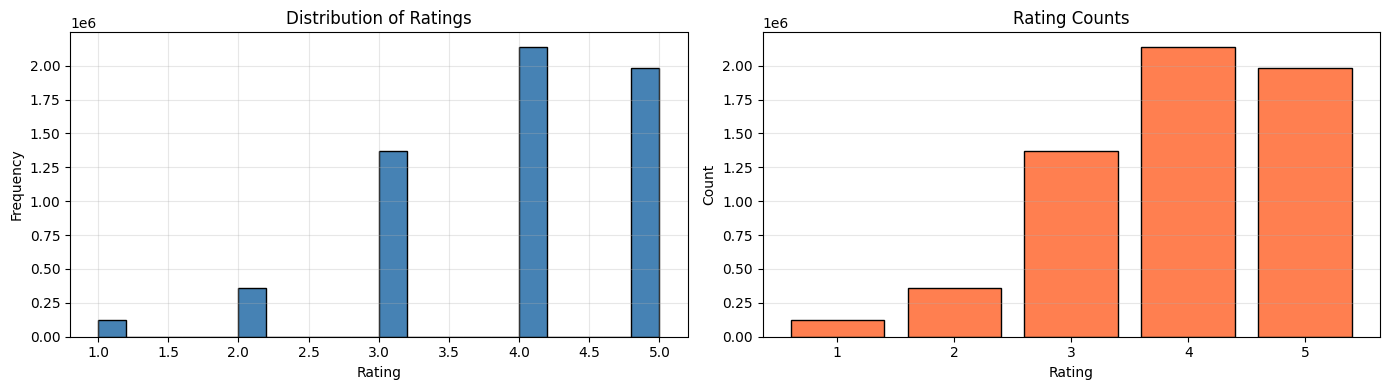

Rating Statistics:
count    5.976471e+06
mean     3.919866e+00
std      9.910863e-01
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [ ]:
# Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(ratings['rating'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Ratings')
axes[0].grid(alpha=0.3)

# Value counts
rating_counts = ratings['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index, rating_counts.values, color='coral', edgecolor='black')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Rating Counts')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Rating Statistics:\n{ratings['rating'].describe()}")

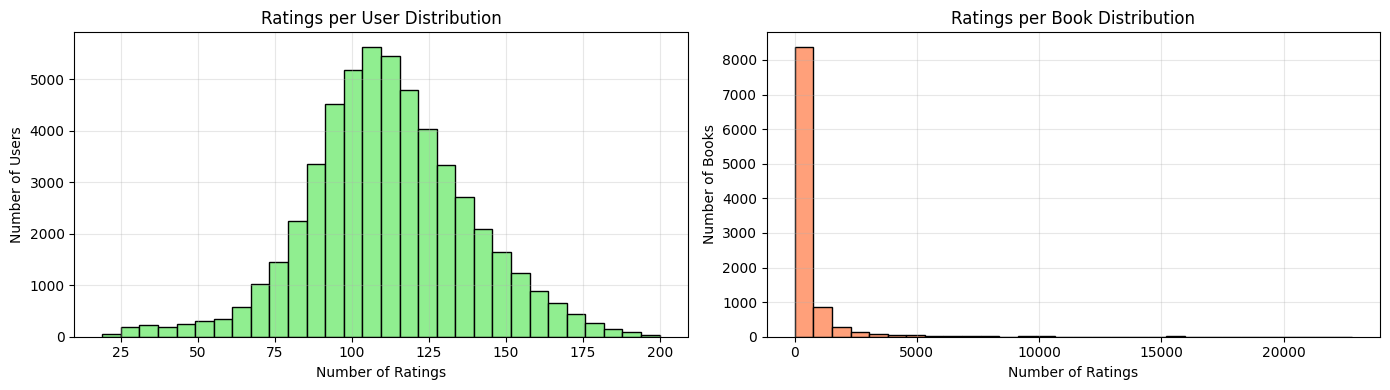

Ratings per user - Min: 19, Max: 200, Mean: 111.87
Ratings per book - Min: 11, Max: 22806, Mean: 597.71


In [ ]:
# User and Book Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Ratings per user
user_rating_counts = ratings.groupby('user_id').size()
axes[0].hist(user_rating_counts, bins=30, color='lightgreen', edgecolor='black')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Ratings per User Distribution')
axes[0].grid(alpha=0.3)

# Ratings per book
book_rating_counts = ratings.groupby('book_id').size()
axes[1].hist(book_rating_counts, bins=30, color='lightsalmon', edgecolor='black')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Books')
axes[1].set_title('Ratings per Book Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ratings per user - Min: {user_rating_counts.min()}, Max: {user_rating_counts.max()}, Mean: {user_rating_counts.mean():.2f}")
print(f"Ratings per book - Min: {book_rating_counts.min()}, Max: {book_rating_counts.max()}, Mean: {book_rating_counts.mean():.2f}")

Top 10 Rated Books (with ≥20 ratings):
         avg_rating  num_ratings
book_id                         
3628       4.829876          482
7947       4.818182           88
9566       4.768707          147
6920       4.766355          214
8978       4.761364          176
6361       4.760456          263
6590       4.757202          243
4483       4.747396          384
3275       4.736842          285
1788       4.728528          652


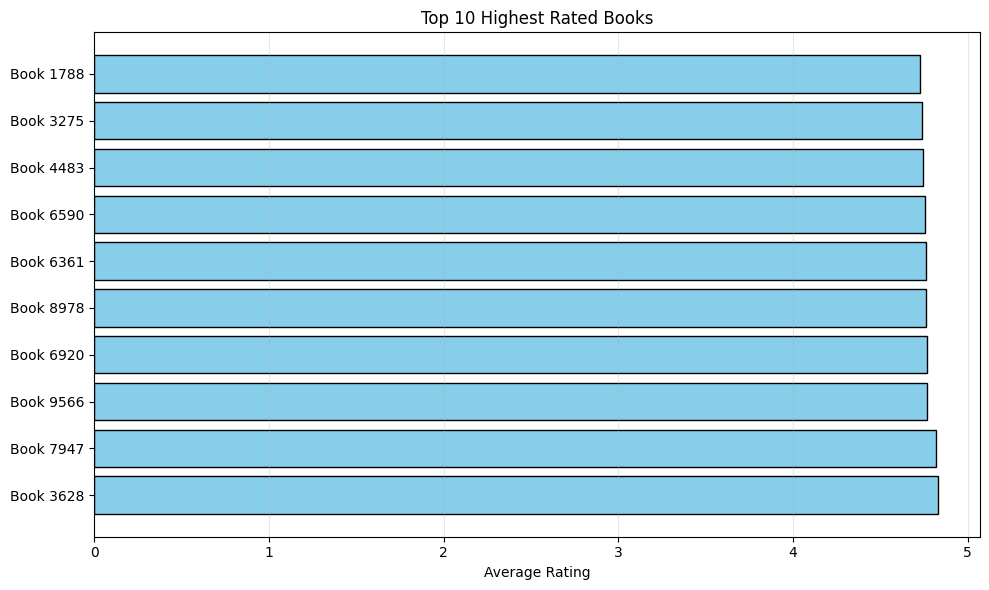

In [ ]:
# Top Rated Books
book_avg_rating = ratings.groupby('book_id').agg({'rating': ['mean', 'count']})
book_avg_rating.columns = ['avg_rating', 'num_ratings']
book_avg_rating = book_avg_rating[book_avg_rating['num_ratings'] >= 20].sort_values('avg_rating', ascending=False)

# Get book titles
top_books = book_avg_rating.head(10)
print("Top 10 Rated Books (with ≥20 ratings):")
print(top_books)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_books)), top_books['avg_rating'], color='skyblue', edgecolor='black')
ax.set_yticks(range(len(top_books)))
ax.set_yticklabels([f"Book {bid}" for bid in top_books.index])
ax.set_xlabel('Average Rating')
ax.set_title('Top 10 Highest Rated Books')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Top 10 Most Rated Books:
         avg_rating  num_ratings
book_id                         
1          4.279707        22806
2          4.351350        21850
4          4.329369        19088
3          3.214341        16931
5          3.772224        16604
17         4.133422        16549
20         3.853131        15953
18         4.418732        15855
23         4.229418        15657
7          4.148477        15558


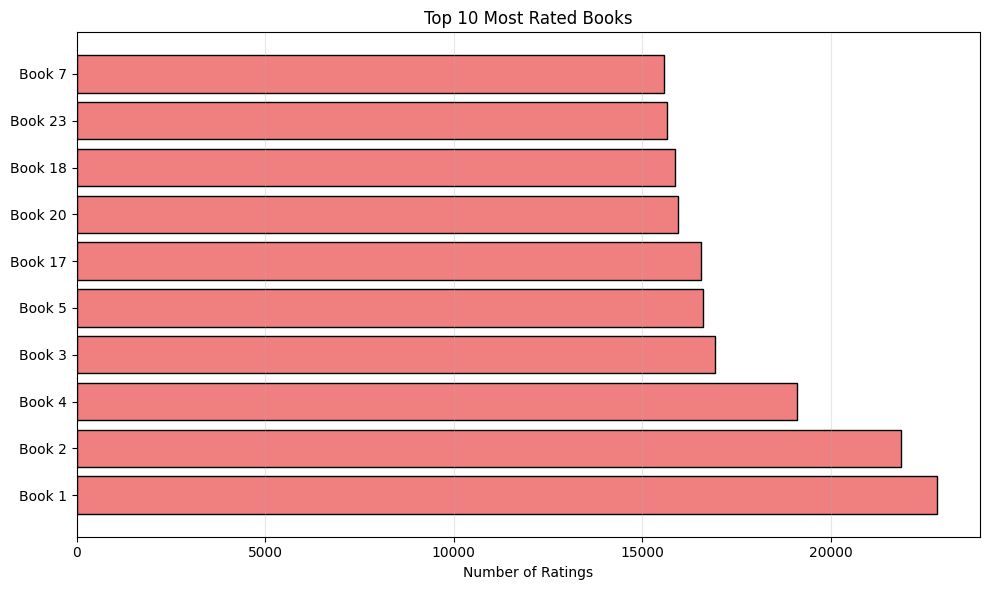

In [ ]:
# Most Popular Books by Number of Ratings
most_rated = book_avg_rating.sort_values('num_ratings', ascending=False).head(10)
print("Top 10 Most Rated Books:")
print(most_rated)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(most_rated)), most_rated['num_ratings'], color='lightcoral', edgecolor='black')
ax.set_yticks(range(len(most_rated)))
ax.set_yticklabels([f"Book {bid}" for bid in most_rated.index])
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 10 Most Rated Books')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Sparsity Analysis
total_possible_ratings = ratings['user_id'].nunique() * ratings['book_id'].nunique()
actual_ratings = len(ratings)
sparsity = (1 - (actual_ratings / total_possible_ratings)) * 100

print(f"\n=== Sparsity Analysis ===")
print(f"Total possible ratings: {total_possible_ratings:,}")
print(f"Actual ratings: {actual_ratings:,}")
print(f"Sparsity: {sparsity:.2f}%")
print(f"Density: {100 - sparsity:.2f}%")


=== Sparsity Analysis ===
Total possible ratings: 534,186,576
Actual ratings: 5,976,471
Sparsity: 98.88%
Density: 1.12%


# 5. EDA Summary

## Key Findings:

1. **Rating Distribution**: Most ratings are concentrated in the higher range (4-5 stars)
2. **User Engagement**: Varies significantly - some users rate many books, others rate few
3. **Book Popularity**: Varies - some books have many ratings, others have few
4. **Data Sparsity**: The rating matrix is sparse (incomplete data coverage)
5. **Top Rated Books**: Books with average ratings above 4.5 are highly recommended
6. **Most Popular**: Some books are rated much more frequently than others

## Recommendations for Modeling:
- Use collaborative filtering (exploits user-item relationships)
- Consider popularity-based recommendations for new users
- Account for sparsity in the recommendation algorithm